# Predicción de Temperaturas Globales
Este proyecto tiene como objetivo analizar datos históricos de temperaturas globales y desarrollar un modelo de Machine Learning capaz de predecir las temperaturas futuras de distintos países. A través de este análisis, buscamos identificar tendencias climáticas y generar predicciones que permitan comprender mejor el impacto del cambio climático.

# Análisis Exploratorio de Datos
Descargar dataset de temperaturas globales de Kaggle https://www.kaggle.com/datasets/vijayvvenkitesh/global-land-temperatures-by-country
y guardar en el archivo GlobalLandTemperaturesByCountry.csv para luego cargarlo

In [ ]:
import pandas as pd

# Cargar el dataset
datos_temperaturas = pd.read_csv("GlobalLandTemperaturesByCountry.csv")

print(datos_temperaturas.head())
print(datos_temperaturas.info())

           dt  AverageTemperature  AverageTemperatureUncertainty Country
0  1743-11-01               4.384                          2.294   Åland
1  1743-12-01                 NaN                            NaN   Åland
2  1744-01-01                 NaN                            NaN   Åland
3  1744-02-01                 NaN                            NaN   Åland
4  1744-03-01                 NaN                            NaN   Åland
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434413 entries, 0 to 434412
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             434413 non-null  object 
 1   AverageTemperature             410164 non-null  float64
 2   AverageTemperatureUncertainty  410903 non-null  float64
 3   Country                        434412 non-null  object 
dtypes: float64(2), object(2)
memory usage: 13.3+ MB
None


**Exploración inicial del dataset**

Después de cargar el dataset, podemos realizar un análisis inicial para entender los datos.


1. Verificar valores nulos

In [ ]:
print(datos_temperaturas.isnull().sum())

dt                                   0
AverageTemperature               24249
AverageTemperatureUncertainty    23510
Country                              1
dtype: int64


2. Verificar estadísticas

In [ ]:
print(datos_temperaturas.describe())

       AverageTemperature  AverageTemperatureUncertainty
count       410164.000000                  410903.000000
mean            16.957372                       1.020556
std             11.072480                       1.204026
min            -37.658000                       0.052000
25%              9.757000                       0.325000
50%             20.471000                       0.574000
75%             25.658000                       1.214000
max             38.842000                      15.003000


3. Identificar el rango temporal

In [ ]:
print("Rango de fechas:", datos_temperaturas['dt'].min(), "a", datos_temperaturas['dt'].max())

Rango de fechas: 1743-11-01 a 2013-09-01


**Selección de columnas relevantes**

Vamos a usar las columnas que necesitamos: dt (fecha), AverageTemperature (temperatura promedio), y Country (país).

In [ ]:
datos_temperaturas = datos_temperaturas[["dt", "AverageTemperature", "Country"]]

# Renombrar columnas para mayor claridad
datos_temperaturas.columns = ["Fecha", "TemperaturaPromedio", "Pais"]

# Mostrar las primeras filas
print(datos_temperaturas.head())

        Fecha  TemperaturaPromedio   Pais
0  1743-11-01                4.384  Åland
1  1743-12-01                  NaN  Åland
2  1744-01-01                  NaN  Åland
3  1744-02-01                  NaN  Åland
4  1744-03-01                  NaN  Åland


# Procesamiento de Datos
Preparamos y limpiamos los datos.

**Manejo de valores nulos**

Identificamos y manejamos los valores nulos en la columna TemperaturaPromedio. Vamos a completar esos valores nulos usando la temperatura promedio del pais correspondiente.

Si un país no tiene ninguna observación válida para la columna TemperaturaPromedio, en este caso, podemos usar la media global como fallback.

In [ ]:
print("Valores nulos por columna:")
print(datos_temperaturas.isnull().sum())

# Reemplazar valores nulos con la media de cada país
datos_temperaturas["TemperaturaPromedio"] = datos_temperaturas.groupby("Pais")["TemperaturaPromedio"].transform(
    lambda x: x.fillna(x.mean())
)

print("Valores nulos después de imputar con la media por país:")
print(datos_temperaturas.isnull().sum())

# Reemplazar valores nulos restantes (si existen) con la media global
datos_temperaturas["TemperaturaPromedio"] = datos_temperaturas["TemperaturaPromedio"].fillna(
    datos_temperaturas["TemperaturaPromedio"].mean()
)

# Verificar nuevamente
print("Valores nulos después de imputar con la media global:")
print(datos_temperaturas.isnull().sum())

Valores nulos por columna:
Fecha                  0
TemperaturaPromedio    0
Pais                   1
dtype: int64
Valores nulos después de imputar con la media por país:
Fecha                  0
TemperaturaPromedio    1
Pais                   1
dtype: int64
Valores nulos después de imputar con la media global:
Fecha                  0
TemperaturaPromedio    0
Pais                   1
dtype: int64


**Conversión de tipos de datos**

Convertimos la columna Fecha a formato de fecha para facilitar el análisis temporal.

In [ ]:
datos_temperaturas["Fecha"] = pd.to_datetime(datos_temperaturas["Fecha"])

print("Rango de fechas:", datos_temperaturas["Fecha"].min(), "a", datos_temperaturas["Fecha"].max())

Rango de fechas: 1743-11-01 00:00:00 a 2013-09-01 00:00:00


**Análisis exploratorio de datos**

**Distribución general de temperaturas**

Visualizamos la distribución de temperaturas en todo el dataset.

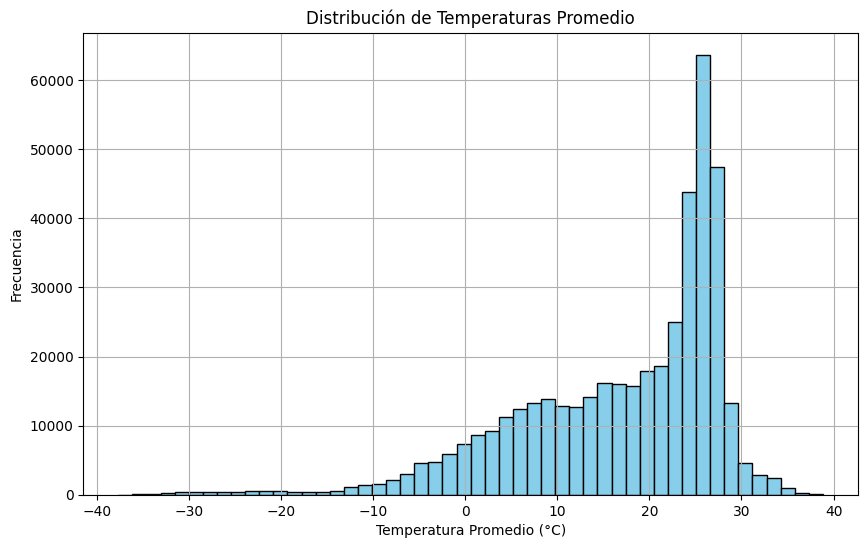

In [ ]:
import matplotlib.pyplot as plt

# Histograma de las temperaturas promedio
plt.figure(figsize=(10, 6))
plt.hist(datos_temperaturas["TemperaturaPromedio"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribución de Temperaturas Promedio")
plt.xlabel("Temperatura Promedio (°C)")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

**Tendencias globales de temperatura a lo largo del tiempo**

Agrupamos las temperaturas globales por año y visualizamos las tendencias.

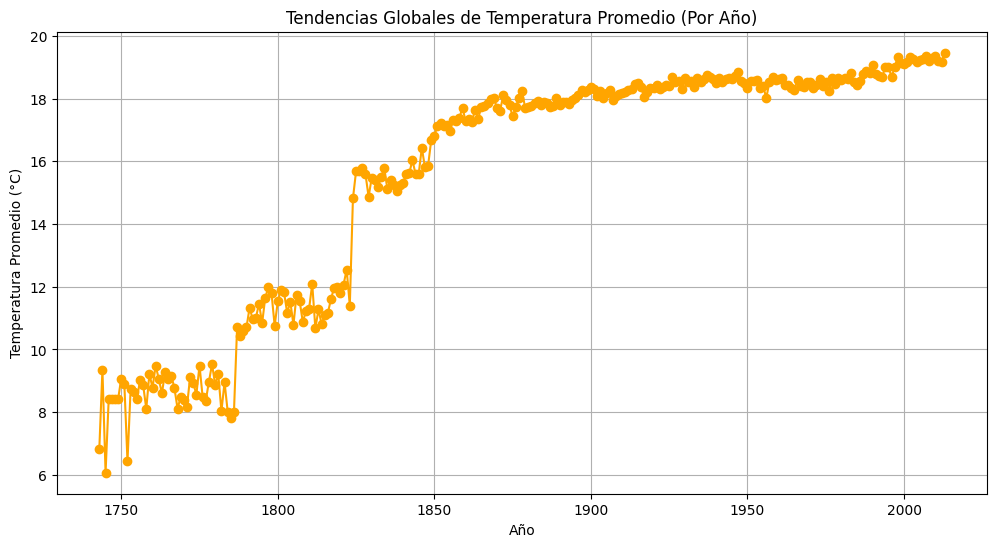

In [ ]:
# Crear una columna 'Año'
datos_temperaturas["Año"] = datos_temperaturas["Fecha"].dt.year

# Agrupar por año y calcular la media
temperaturas_anuales = datos_temperaturas.groupby("Año")["TemperaturaPromedio"].mean()

# Visualizar la tendencia
plt.figure(figsize=(12, 6))
plt.plot(temperaturas_anuales.index, temperaturas_anuales.values, marker='o', color='orange')
plt.title("Tendencias Globales de Temperatura Promedio (Por Año)")
plt.xlabel("Año")
plt.ylabel("Temperatura Promedio (°C)")
plt.grid()
plt.show()

**Comparación por países**

Analizar y comparar las temperaturas promedio por país

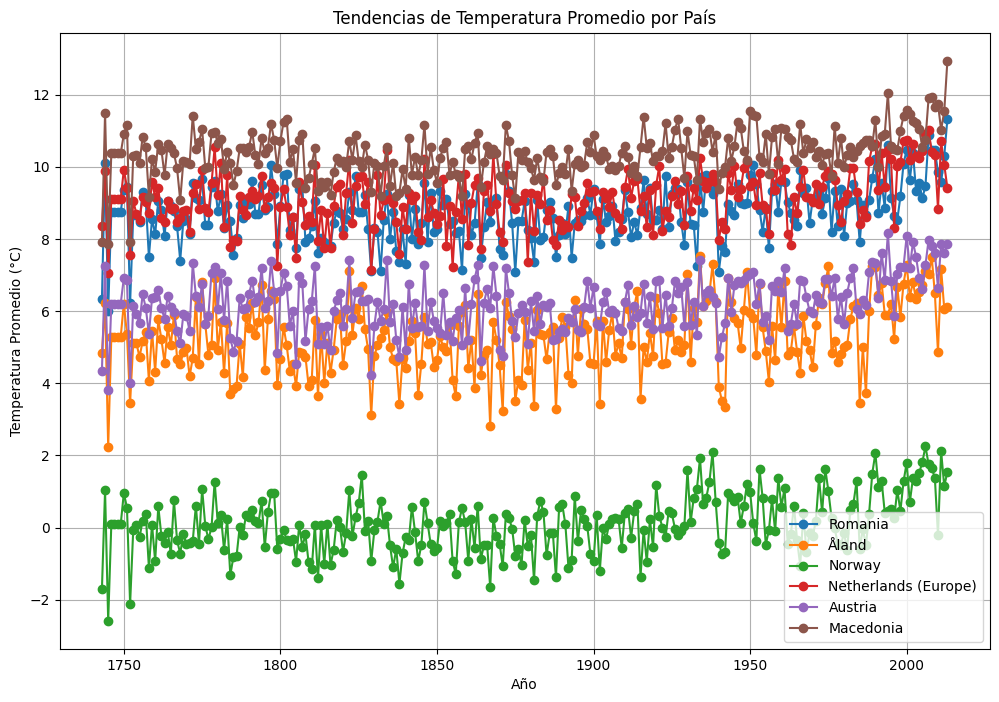

In [ ]:
# Seleccionar los 6 países con más datos
paises_top = datos_temperaturas["Pais"].value_counts().head(6).index

# Filtrar los datos para estos países
datos_top_paises = datos_temperaturas[datos_temperaturas["Pais"].isin(paises_top)]

# Visualizar las tendencias por país
plt.figure(figsize=(12, 8))
for pais in paises_top:
    temperaturas_pais = datos_top_paises[datos_top_paises["Pais"] == pais].groupby("Año")["TemperaturaPromedio"].mean()
    plt.plot(temperaturas_pais.index, temperaturas_pais.values, marker='o', label=pais)

plt.title("Tendencias de Temperatura Promedio por País")
plt.xlabel("Año")
plt.ylabel("Temperatura Promedio (°C)")
plt.legend()
plt.grid()
plt.show()

**Preparación para el modelado**

**Filtrar datos para entrenamiento**

Seleccionaremos un rango de años y usamos las columnas relevantes para modelar

In [ ]:
# Filtrar datos desde 1900
datos_filtrados = datos_temperaturas[datos_temperaturas["Año"] >= 1900]

# Seleccionar columnas para el modelo
datos_modelo = datos_filtrados[["Año", "Pais", "TemperaturaPromedio"]]

print(datos_modelo.head())

       Año   Pais  TemperaturaPromedio
1874  1900  Åland               -3.026
1875  1900  Åland               -8.063
1876  1900  Åland               -3.196
1877  1900  Åland                0.781
1878  1900  Åland                4.960


**Codificación de variables categóricas**

Convertimos la columna Pais en una representación numérica

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
datos_modelo["PaisCodificado"] = encoder.fit_transform(datos_modelo["Pais"])

print(datos_modelo.head())

       Año   Pais  TemperaturaPromedio  PaisCodificado
1874  1900  Åland               -3.026             182
1875  1900  Åland               -8.063             182
1876  1900  Åland               -3.196             182
1877  1900  Åland                0.781             182
1878  1900  Åland                4.960             182


**Dividir los datos en entrenamiento y prueba**

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [ ]:
from sklearn.model_selection import train_test_split

X = datos_modelo[["Año", "PaisCodificado"]]
y = datos_modelo["TemperaturaPromedio"]

print("Variables X:")
print(X.head())
print("\nVariable Y:")
print(y.head())

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar las dimensiones de los conjuntos
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Variables X:
       Año  PaisCodificado
1874  1900             182
1875  1900             182
1876  1900             182
1877  1900             182
1878  1900             182

Variable Y:
1874   -3.026
1875   -8.063
1876   -3.196
1877    0.781
1878    4.960
Name: TemperaturaPromedio, dtype: float64
Tamaño del conjunto de entrenamiento: (198176, 2)
Tamaño del conjunto de prueba: (49544, 2)


**Escalamiento de datos**

El rango de los valores de las variables (Año y PaisCodificado) puede ser muy diferente, por lo que escalamos las variables usando StandardScaler para mejorar el rendimiento del modelo.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados (primeros 5 registros de X_train_scaled):")
print(X_train_scaled[:5])

Datos escalados (primeros 5 registros de X_train_scaled):
[[ 1.0195348  -0.81422865]
 [ 0.5621774  -0.6627361 ]
 [ 0.80610135 -1.62850106]
 [ 1.5073827   1.00368185]
 [ 1.35493023 -0.6627361 ]]


# Modelado Predictivo
A continuacion vamos a implementar y evaluar distintos algoritmos de Machine Learning para predecir las temperaturas futuras.

**Regresión Lineal para la Predicción de Temperaturas Globales** 📈

Usamos Linear Regression para predecir las temperaturas. Aunque se trata de un modelo básico, nos permite establecer una base para comparar con modelos más avanzados.

In [ ]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

print("Coeficientes del modelo:", modelo.coef_)
print("Intercepto del modelo:", modelo.intercept_)

Coeficientes del modelo: [ 0.28355731 -0.13899331]
Intercepto del modelo: 18.823487515402793


**Evaluación del Rendimiento**

Para evaluar el rendimiento, usamos dos métricas clave:
1. RMSE (Root Mean Squared Error): Error promedio de predicción.
2.	MAE (Mean Absolute Error): Error promedio absoluto de las predicciones.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = modelo.predict(X_test_scaled)

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)

print("RMSE (Error Cuadrático Medio):", rmse)
print("MAE (Error Absoluto Medio):", mae)

RMSE (Error Cuadrático Medio): 10.469331484525974
MAE (Error Absoluto Medio): 8.350373638386689


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Para analizar cómo el modelo se desempeña, graficamos las predicciones frente a los valores reales. Idealmente, los puntos deberían alinearse con la línea roja, que representa las predicciones perfectas.

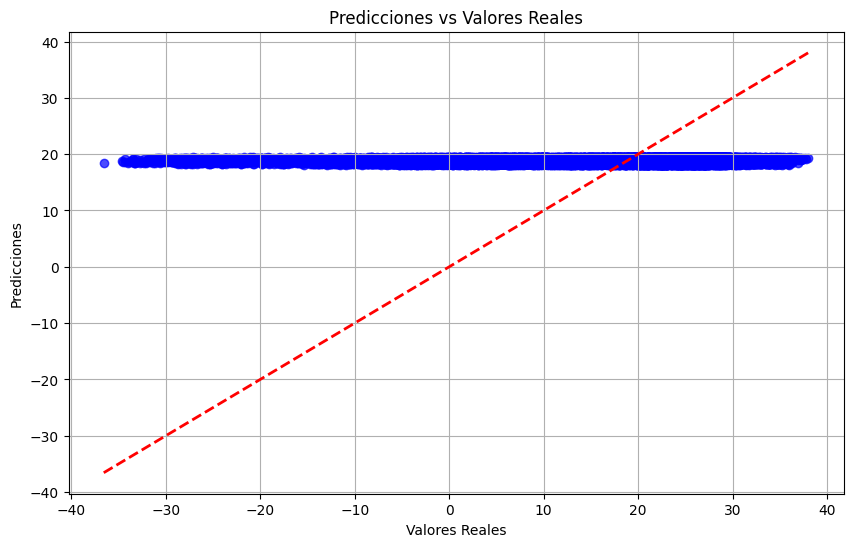

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
plt.title("Predicciones vs Valores Reales")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.grid()
plt.show()

Para tener una visión más clara, comparamos los primeros 10 valores reales con sus predicciones.

In [ ]:
# Crear un DataFrame para comparar predicciones y valores reales
import pandas as pd

# Crear el DataFrame
resultados = pd.DataFrame({
    "Valores Reales": y_test,
    "Predicciones": y_pred
}).reset_index(drop=True)

# Mostrar las primeras filas
print(resultados.head(10))

   Valores Reales  Predicciones
0          25.182     18.880460
1          23.745     18.569730
2          24.992     18.875013
3          13.334     18.429560
4          24.659     19.241807
5          27.239     19.246312
6          -0.831     18.971751
7          30.546     18.379840
8          26.503     18.583402
9          26.079     18.778330


**Conclusión**

Hay una gran dispersión en los puntos, lo que indica que el modelo tiene dificultades para capturar la relación entre las características y la variable objetivo.

Los valores altos de RMSE y MAE confirman que el modelo tiene un rendimiento malo. La dispersión de los puntos alrededor de la línea ideal en el grafico respalda la necesidad de usar modelos más avanzados.

En conclusion, la regresión lineal no es adecuada para este problema.

**Redes Neuronales** 🧠

En este caso utilizaremos un modelo de redes neuronales para predecir las temperaturas.
Las redes neuronales son sensibles a los valores de entrada, por eso primero vamos a escalar los datos para mejorar la convergencia y el rendimiento del modelo.

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

**Diseño de la Red Neuronal**

Creamos una red neuronal con las siguientes caracteristicas:

	•	Capa de entrada
	•	Capas ocultas: Dos capas ocultas con activación ReLU
	•	Capa de salida: Produce una salida continua
	•	Optimizador: vamos a usar Adam
	•	Pérdida: MSE (Error Cuadrático Medio)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

modelo_nn = Sequential()

# Capa de entrada
modelo_nn.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
modelo_nn.add(Dense(32, activation='relu'))

# Capa de salida
modelo_nn.add(Dense(1, activation='linear'))

modelo_nn.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

modelo_nn.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

**Entrenamiento del Modelo**

Entrenamos el modelo usando 50 epochs y un tamaño de lote de 32. También incluimos un conjunto de validación para monitorear el desempeño.

In [ ]:
historial = modelo_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 130.5777 - mean_absolute_error: 9.0950 - val_loss: 109.5853 - val_mean_absolute_error: 8.4296
Epoch 2/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 109.5589 - mean_absolute_error: 8.3373 - val_loss: 109.4348 - val_mean_absolute_error: 8.2506
Epoch 3/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - loss: 109.5780 - mean_absolute_error: 8.3347 - val_loss: 109.2963 - val_mean_absolute_error: 8.2576
Epoch 4/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 108.8210 - mean_absolute_error: 8.2888 - val_loss: 109.2329 - val_mean_absolute_error: 8.2223
Epoch 5/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 109.5203 - mean_absolute_error: 8.3095 - val_loss: 109.0725 - val_mean_absolute_error: 8.2262
Epoch 6/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 109.4057 - mean_absolute_error: 8.3130 - val_loss: 108.8846 - val_mean_absolute_error: 8.2160
Epoch 7/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - l

**Evaluación del Modelo**

Evaluamos el modelo en el conjunto de prueba usando las métricas de pérdida (MSE) y error absoluto medio (MAE).

In [ ]:
resultados = modelo_nn.evaluate(X_test_scaled, y_test)
print(f"Pérdida (Mean Squared Error): {resultados[0]}")
print(f"Error Absoluto Medio (MAE): {resultados[1]}")

2062/2062 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 107.7457 - mean_absolute_error: 8.0829
Pérdida (Mean Squared Error): 106.87605285644531
Error Absoluto Medio (MAE): 8.057501792907715


**Visualización del rendimiento**

Graficamos la pérdida de entrenamiento y validación para analizar si el modelo está aprendiendo bien o si hay overfitting.

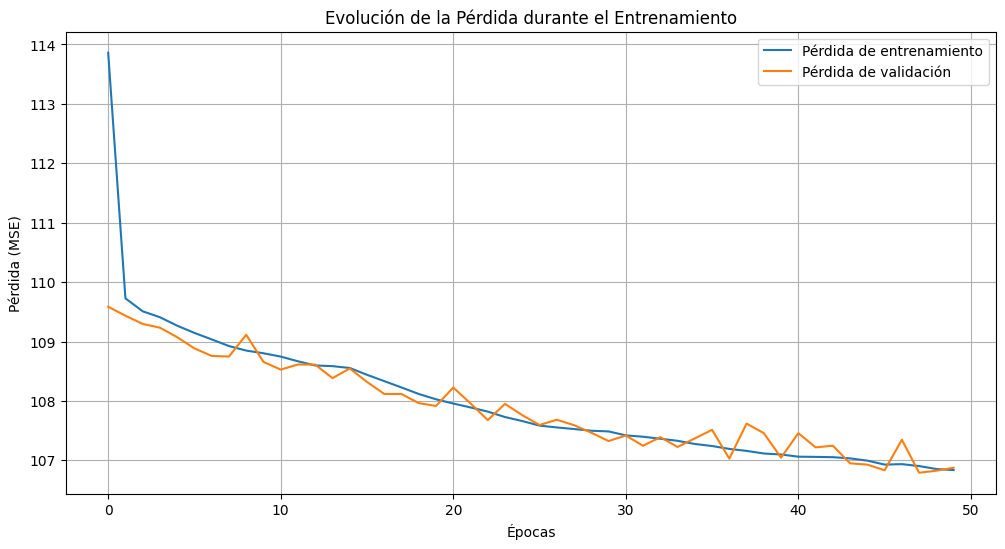

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(historial.history['loss'], label='Pérdida de entrenamiento')
plt.plot(historial.history['val_loss'], label='Pérdida de validación')
plt.title('Evolución de la Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid()
plt.show()

Tanto la pérdida de entrenamiento como la de validación disminuyen con las epochs, lo que indica que el modelo está aprendiendo a ajustar sus parámetros para minimizar el error.

Las curvas de pérdida de entrenamiento y validación son parecidas, lo que sugiere que no hay un problema de overfitting.


Generamos predicciones con la red neuronal entrenada y las comparamos con los valores reales.

2062/2062 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
   Valores Reales  Predicciones NN
0          25.182        21.034855
1          23.745        20.626591
2          24.992        20.283411
3          13.334        18.416340
4          24.659        17.916170
5          27.239        20.350975
6          -0.831        17.334265
7          30.546        19.156071
8          26.503        17.050304
9          26.079        19.845953


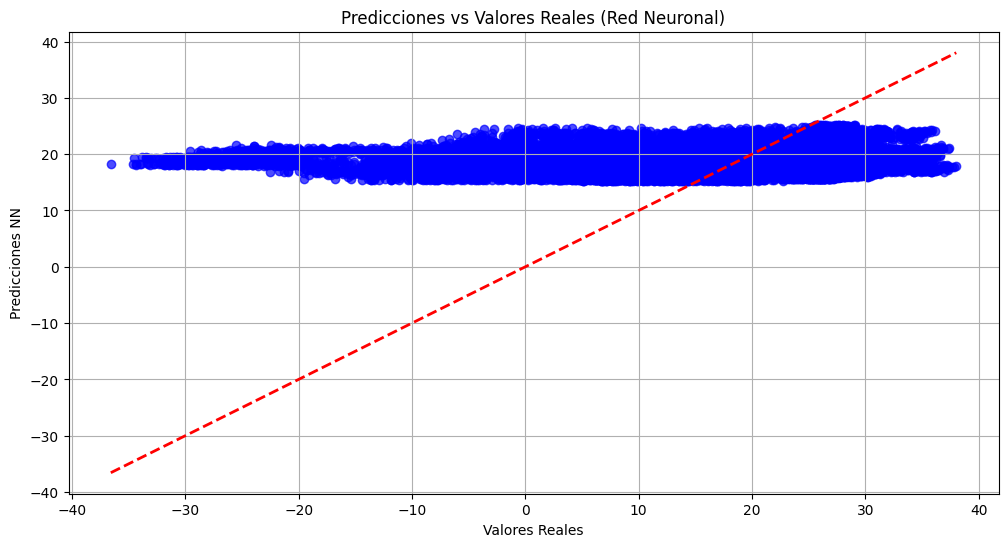

In [ ]:
# Predicciones en el conjunto de prueba
y_pred_nn = modelo_nn.predict(X_test_scaled)

# Comparación con valores reales
import pandas as pd

resultados_nn = pd.DataFrame({
    "Valores Reales": y_test.flatten(),
    "Predicciones NN": y_pred_nn.flatten()
})

print(resultados_nn.head(10))

# Visualizar las predicciones vs valores reales
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Predicciones vs Valores Reales (Red Neuronal)')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones NN')
plt.grid()
plt.show()

**Conclusion**

El modelo de redes neuronales implementado no logró capturar adecuadamente la relación entre las variables predictoras y la temperatura promedio.

Los valores de RMSE y MAE indican un error considerable en las predicciones.

Las predicciones se concentran en un rango estrecho y están alejadas de la línea ideal, reflejando una incapacidad del modelo

**Gradient Boosting** 🌳

Usaremos GradientBoostingRegressor para entrenar el modelo y evaluar su rendimiento.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

rmse_gb = mean_squared_error(y_test, y_pred_gb, squared=False)
mae_gb = mean_absolute_error(y_test, y_pred_gb)

print("Resultados de Gradient Boosting:")
print(f"RMSE: {rmse_gb}")
print(f"MAE: {mae_gb}")

Resultados de Gradient Boosting:
RMSE: 7.911537368594708
MAE: 6.096248245118594


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Visualizar Predicciones vs Valores Reales

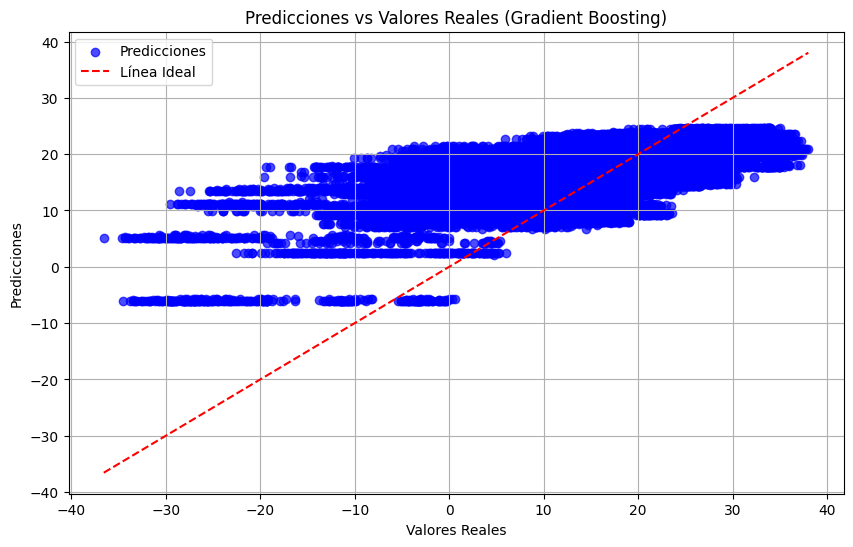

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_gb, alpha=0.7, color='blue', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea Ideal')
plt.title('Predicciones vs Valores Reales (Gradient Boosting)')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir el rango de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# Realizar la búsqueda en cuadrícula
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,  # Validación cruzada
    verbose=1
)

# Entrenar el modelo con la búsqueda
grid_search.fit(X_train, y_train)

# Mejor combinación de hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Usar el mejor modelo encontrado
best_gb_model = grid_search.best_estimator_

# Predicciones y evaluación con el mejor modelo
y_pred_best_gb = best_gb_model.predict(X_test)
rmse_best_gb = mean_squared_error(y_test, y_pred_best_gb, squared=False)
mae_best_gb = mean_absolute_error(y_test, y_pred_best_gb)

print("Resultados del Mejor Gradient Boosting:")
print(f"RMSE: {rmse_best_gb}")
print(f"MAE: {mae_best_gb}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Mejores hiperparámetros: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 300}
Resultados del Mejor Gradient Boosting:
RMSE: 5.231765077431587
MAE: 3.604339707987946


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


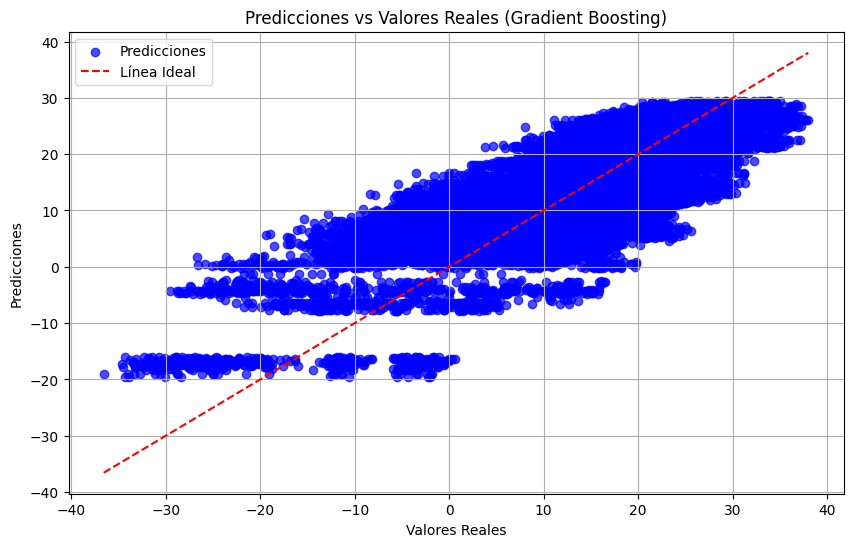

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best_gb, alpha=0.7, color='blue', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea Ideal')
plt.title('Predicciones vs Valores Reales (Gradient Boosting)')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.grid()
plt.show()

**Random Forest** 🌴

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

rf_model = RandomForestRegressor(
    n_estimators=100,  # Número de árboles en el bosque
    max_depth=None,    # Sin límite de profundidad para los árboles
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)  # RMSE
mae_rf = mean_absolute_error(y_test, y_pred_rf)  # MAE

print("Resultados de Random Forest:")
print(f"RMSE: {rmse_rf}")
print(f"MAE: {mae_rf}")

Resultados de Random Forest:
RMSE: 5.714984979660103
MAE: 3.8904362831935773


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Predicciones vs Valores Reales

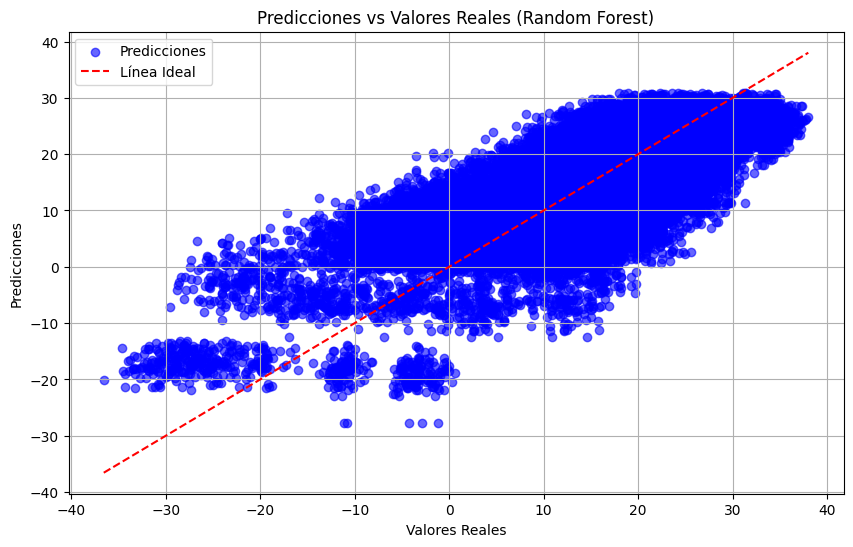

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, color='blue', label='Predicciones', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea Ideal')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

**Multilayer Perceptron** 🧠

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 130.4142 - mae: 9.0855 - val_loss: 109.3215 - val_mae: 8.2182
Epoch 2/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: 109.6021 - mae: 8.3307 - val_loss: 108.9541 - val_mae: 8.3401
Epoch 3/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 108.4616 - mae: 8.2748 - val_loss: 109.2932 - val_mae: 8.1747
Epoch 4/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 109.3881 - mae: 8.3007 - val_loss: 108.4522 - val_mae: 8.2258
Epoch 5/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 108.4917 - mae: 8.2583 - val_loss: 108.1676 - val_mae: 8.2771
Epoch 6/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 107.9983 - mae: 8.2395 - val_loss: 108.1577 - val_mae: 8.1729
Epoch 7/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 108.1212 - mae: 8.2292 - val_loss: 108.0247 - val_mae: 8.1901
Epoch 8/50
8247/8247 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 107.4593 - mae: 8.2032 - val_loss: 107.8840 - val_mae: 8.2853


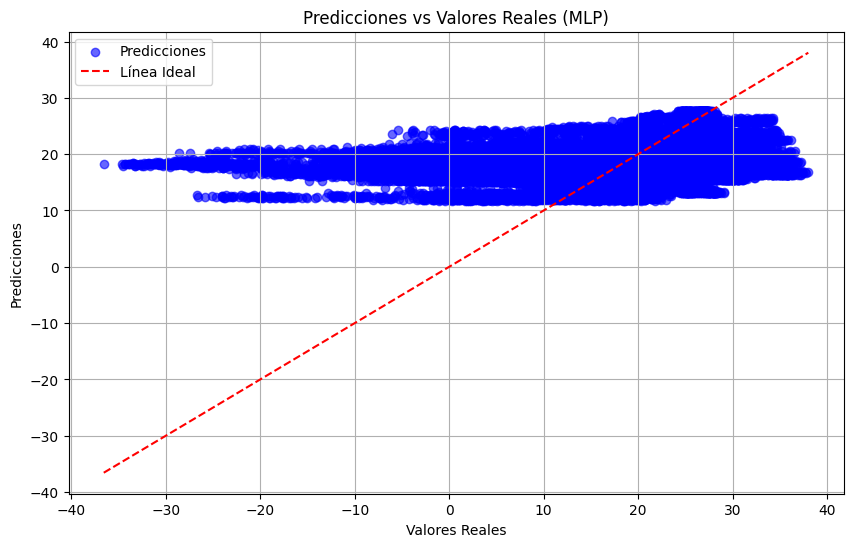

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Escalamos los datos para mejorar la convergencia del modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear el modelo
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

y_pred_mlp = model.predict(X_test_scaled)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)

print("Resultados de MLP:")
print(f"RMSE: {rmse_mlp}")
print(f"MAE: {mae_mlp}")

# Graficar predicciones vs valores reales
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_mlp, color='blue', label='Predicciones', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea Ideal')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales (MLP)')
plt.legend()
plt.grid(True)
plt.show()

**Gradient Boosting Mejorado** 🌲

En esta sección, se busca mejorar el rendimiento del modelo Gradient Boosting Regressor mediante una optimización avanzada de hiperparámetros utilizando RandomizedSearchCV.

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
54 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

Mejores hiperparámetros: {'learning_rate': 0.2000589132282684, 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400, 'subsample': 1.0}


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Resultados del Gradient Boosting Optimizado:
RMSE: 5.3977294336758
MAE: 3.7350842730867058


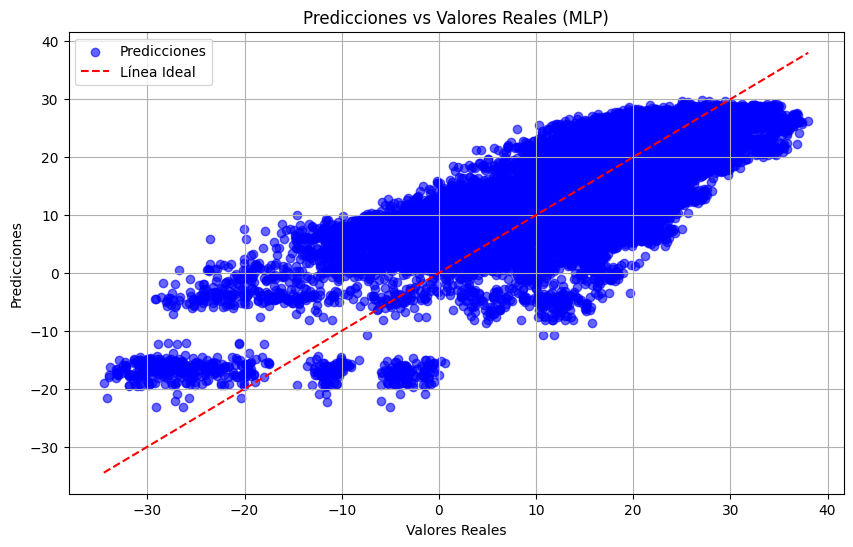

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Rango de hiperparámetros
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['auto', 'sqrt', 'log2']
}

# RandomizedSearchCV para búsqueda más eficiente
random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    scoring='neg_mean_squared_error',
    n_iter=50,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", random_search.best_params_)
best_gb_model = random_search.best_estimator_

# Evaluar el modelo
y_pred_optimized = best_gb_model.predict(X_test)
rmse_optimized = mean_squared_error(y_test, y_pred_optimized, squared=False)
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)

print("Resultados del Gradient Boosting Optimizado:")
print(f"RMSE: {rmse_optimized}")
print(f"MAE: {mae_optimized}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_optimized, color='blue', label='Predicciones', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea Ideal')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales (MLP)')
plt.legend()
plt.grid(True)
plt.show()

**Conclusion**

La optimización con RandomizedSearchCV permitió encontrar la configuración óptima para los hiperparámetros del modelo, mejorando significativamente su precisión.

# Conclusiones

El objetivo del proyecto era desarrollar modelos de Machine Learning capaces de predecir temperaturas promedio globales utilizando un dataset histórico. A lo largo del desarrollo, se evaluaron diversos enfoques, incluyendo regresión lineal, redes neuronales y métodos avanzados como Gradient Boosting y Random Forest.

Gradient Boosting logró los mejores resultados con un RMSE de 5.23 y un MAE de 3.60, mostrando su capacidad para capturar patrones complejos en los datos. La optimización de hiperparámetros mejoró significativamente el rendimiento, destacando la importancia de esta etapa en el pipeline de Machine Learning.

Desempeño de otros modelos:
- Regresión Lineal: Este modelo no fue adecuado debido a su incapacidad para modelar las relaciones no lineales presentes en los datos. Los errores (RMSE y MAE) fueron significativamente mayores.
- Redes Neuronales: Las redes neuronales no lograron buenos resultados debido al underfitting. Esto podría deberse a la necesidad de más datos, una arquitectura más robusta o una mayor cantidad de epochs.

### Integrantes:
* Gastón Cuevas
* Mariano Sanchez de Vera
* Francisco Zanetti